In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [2]:
file_path = "combined.csv"

df = pd.read_csv(file_path)

print("First 5 rows:")
print(df.head())
print("\nShape of dataset:")
print(df.shape)

First 5 rows:
   age  sex  chest pain type  resting bp s  cholesterol  fasting blood sugar  \
0   52    1                1         125.0        212.0                    0   
1   53    1                1         140.0        203.0                    1   
2   70    1                1         145.0        174.0                    0   
3   61    1                1         148.0        203.0                    0   
4   62    0                1         138.0        294.0                    1   

   resting ecg  max heart rate  exercise angina  oldpeak  ST slope  target  
0            1             168                0      1.0         2       0  
1            0             155                1      3.1         0       0  
2            1             125                1      2.6         0       0  
3            1             161                0      0.0         2       0  
4            1             106                0      1.9         1       0  

Shape of dataset:
(1220, 12)


In [3]:
df.head()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1220 entries, 0 to 1219
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  1220 non-null   int64  
 1   sex                  1220 non-null   int64  
 2   chest pain type      1220 non-null   int64  
 3   resting bp s         1219 non-null   float64
 4   cholesterol          1048 non-null   float64
 5   fasting blood sugar  1220 non-null   int64  
 6   resting ecg          1220 non-null   int64  
 7   max heart rate       1220 non-null   int64  
 8   exercise angina      1220 non-null   int64  
 9   oldpeak              1220 non-null   float64
 10  ST slope             1220 non-null   int64  
 11  target               1220 non-null   int64  
dtypes: float64(3), int64(9)
memory usage: 114.5 KB


In [4]:
df.dtypes

age                      int64
sex                      int64
chest pain type          int64
resting bp s           float64
cholesterol            float64
fasting blood sugar      int64
resting ecg              int64
max heart rate           int64
exercise angina          int64
oldpeak                float64
ST slope                 int64
target                   int64
dtype: object

In [5]:
df["ST slope"] = df["ST slope"].replace(0, np.nan)

In [6]:
df.isna().sum()

age                      0
sex                      0
chest pain type          0
resting bp s             1
cholesterol            172
fasting blood sugar      0
resting ecg              0
max heart rate           0
exercise angina          0
oldpeak                  0
ST slope                22
target                   0
dtype: int64

<Axes: xlabel='target', ylabel='count'>

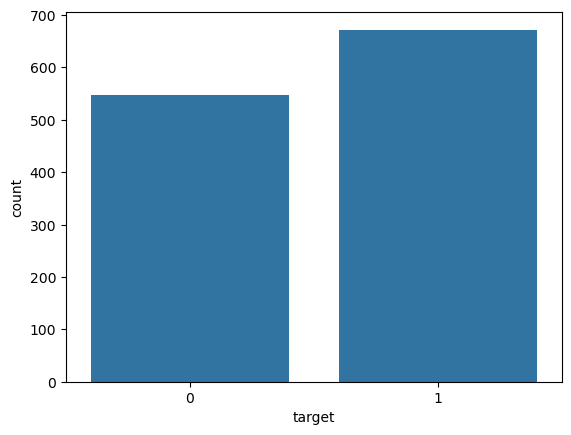

In [7]:
df["target"].value_counts()
sns.countplot(x="target", data=df)

In [8]:
bp_index = df[df['resting bp s'].isna()].index

df.drop(bp_index, inplace=True)

In [9]:
df.isna().sum()

age                      0
sex                      0
chest pain type          0
resting bp s             0
cholesterol            171
fasting blood sugar      0
resting ecg              0
max heart rate           0
exercise angina          0
oldpeak                  0
ST slope                22
target                   0
dtype: int64

In [10]:
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC

In [11]:
X = df.drop("target", axis=1)
y = df["target"]

In [12]:
numerical_nan = ["cholesterol"]
numerical_clean = ["age", "resting bp s", "max heart rate", "oldpeak"]

categorical_nan = ["ST slope"]
categorical_clean = ["chest pain type", "resting ecg"]

binary_features = ["sex", "fasting blood sugar", "exercise angina"]



In [13]:
numerical_nan_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

numerical_clean_transformer = Pipeline([
    ("scaler", StandardScaler())
])

categorical_nan_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

categorical_clean_transformer = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [14]:
preprocess = ColumnTransformer([
    ("num_nan", numerical_nan_transformer, numerical_nan),
    ("num_clean", numerical_clean_transformer, numerical_clean),
    ("cat_nan", categorical_nan_transformer, categorical_nan),
    ("cat_clean", categorical_clean_transformer, categorical_clean),
    ("bin", "passthrough", binary_features)
])

In [15]:
print(X.shape)
print(y.shape)
print(y.value_counts())

(1219, 11)
(1219,)
target
1    671
0    548
Name: count, dtype: int64


In [16]:
pipeline = Pipeline([
    ("preprocess", preprocess),
    ("model", SVC(kernel="rbf"))
])

In [17]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [18]:
scores = cross_val_score(pipeline, X, y, cv=skf, scoring="accuracy")

In [19]:
print("Accuracy of each fold:")
print(scores)

print("\nMean accuracy:")
print(scores.mean())

print("\nStandard deviation of accuracy:")
print(scores.std())

Accuracy of each fold:
[0.80737705 0.77459016 0.79098361 0.82377049 0.82304527]

Mean accuracy:
0.8039533157930243

Standard deviation of accuracy:
0.018970256084964773


In [20]:
results = cross_validate(pipeline, X, y, cv=skf, scoring=["accuracy", "precision", "recall", "f1"], return_train_score=False)

In [21]:
print("Mean Accuracy :", results["test_accuracy"].mean())
print("Mean Precision:", results["test_precision"].mean())
print("Mean Recall   :", results["test_recall"].mean())
print("Mean F1-score :", results["test_f1"].mean())

Mean Accuracy : 0.8039533157930243
Mean Precision: 0.8088960713310331
Mean Recall   : 0.8434825870646767
Mean F1-score : 0.8257484735101258


In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [23]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = [
    {
        "model__kernel": ["linear"],
        "model__C": [0.01, 0.1, 1, 10, 100]
    },
    {
        "model__kernel": ["rbf"],
        "model__C": [0.01, 0.1, 1, 10, 100, 1000],
        "model__gamma": ["scale", "auto", 0.1, 0.01, 0.001]
    }
]

grid = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=skf, scoring="f1", n_jobs=-1, verbose=1)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 35 candidates, totalling 175 fits


,estimator,"Pipeline(step...del', SVC())])"
,param_grid,"[{'model__C': [0.01, 0.1, ...], 'model__kernel': ['linear']}, {'model__C': [0.01, 0.1, ...], 'model__gamma': ['scale', 'auto', ...], 'model__kernel': ['rbf']}]"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num_nan', ...), ('num_clean', ...), ...]"


In [24]:
print("Best Parameters:")
print(grid.best_params_)

print("\nBest Cross-Validation Score:")
print(grid.best_score_)

Best Parameters:
{'model__C': 100, 'model__gamma': 0.01, 'model__kernel': 'rbf'}

Best Cross-Validation Score:
0.8312478139966647


In [25]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

print("Test Accuracy :", accuracy_score(y_test, y_pred))
print("Test Precision:", precision_score(y_test, y_pred))
print("Test Recall   :", recall_score(y_test, y_pred))
print("Test F1-score :", f1_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Test Accuracy : 0.8278688524590164
Test Precision: 0.8432835820895522
Test Recall   : 0.8432835820895522
Test F1-score : 0.8432835820895522

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.81      0.81       110
           1       0.84      0.84      0.84       134

    accuracy                           0.83       244
   macro avg       0.83      0.83      0.83       244
weighted avg       0.83      0.83      0.83       244



Confusion Matrix:
[[ 89  21]
 [ 21 113]]


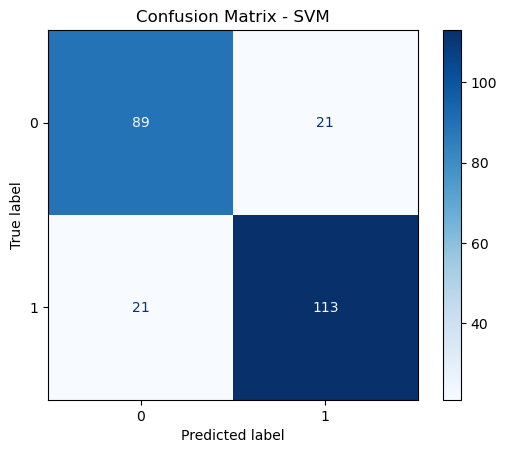

In [27]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - SVM")
plt.savefig("Confusion Matrix_SVM.png", dpi=300)
plt.show()

In [28]:
from sklearn.inspection import permutation_importance

result = permutation_importance( best_model, X_test, y_test, n_repeats=20, random_state=42)

importance = pd.DataFrame({
"feature":X.columns,
"importance":result.importances_mean
})

importance = importance.sort_values("importance",ascending=False)

print(importance)

                feature  importance
10             ST slope    0.182992
2       chest pain type    0.092623
9               oldpeak    0.018852
5   fasting blood sugar    0.014549
3          resting bp s    0.011680
1                   sex    0.009221
4           cholesterol    0.004918
6           resting ecg    0.003279
0                   age    0.001844
7        max heart rate    0.001639
8       exercise angina   -0.001434
